In [2]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_parquet("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-02.parquet")

In [4]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,7,2026-02-01 00:05:57,2026-02-01 00:05:57,1.0,0.94,1.0,N,107,170,1,7.2,0.00,0.5,0.00,0.0,1.0,12.95,2.5,0.00,0.75
1,7,2026-02-01 00:35:58,2026-02-01 00:35:58,1.0,1.93,1.0,N,234,141,1,11.4,0.00,0.5,3.43,0.0,1.0,20.58,2.5,0.00,0.75
2,2,2026-02-01 00:08:41,2026-02-01 00:39:32,1.0,9.99,1.0,N,138,68,1,44.3,6.00,0.5,11.01,0.0,1.0,67.81,2.5,1.75,0.75
3,1,2026-02-01 00:29:06,2026-02-01 00:41:04,0.0,1.70,1.0,N,209,13,1,12.8,4.25,0.5,3.70,0.0,1.0,22.25,2.5,0.00,0.75
4,1,2026-02-01 00:53:52,2026-02-01 01:11:21,0.0,3.70,1.0,N,249,229,1,19.8,4.25,0.5,6.35,0.0,1.0,31.90,2.5,0.00,0.75


In [5]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression , Lasso , Ridge
from sklearn.metrics import root_mean_squared_error

In [6]:
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [7]:
df['duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df['duration']=df['duration'].apply(lambda td : td.total_seconds() / 60 ) #conversion in min

In [8]:
df['duration'].describe(percentiles = [0.95,0.98,0.991,0.999])
#going to perform capping on outliers , 25%tile = min , and max -> 75


count    3.399866e+06
mean     1.784104e+01
std      2.521706e+01
min     -1.050000e+00
50%      1.401667e+01
95%      4.378333e+01
98%      5.990000e+01
99.1%    7.453333e+01
99.9%    1.248833e+02
max      9.265150e+03
Name: duration, dtype: float64

In [9]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']
df[categorical] = df[categorical].astype(str)

In [10]:
train_dicts = df[categorical+numerical].to_dict(orient='records')# orient = records -> list of dictionaries
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
target = 'duration'
y_train = df[target].values
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred =lr.predict(X_train)
print(root_mean_squared_error(y_train,y_pred))

24.038802852292417


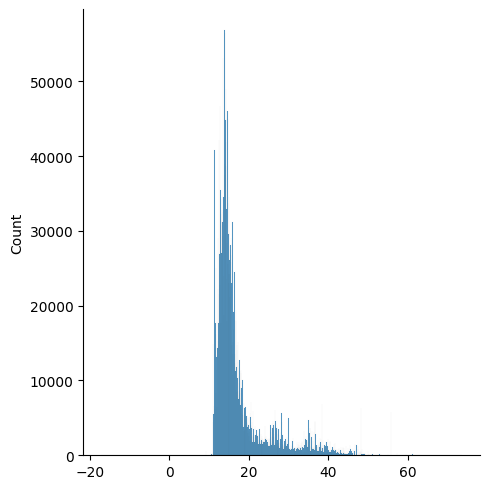

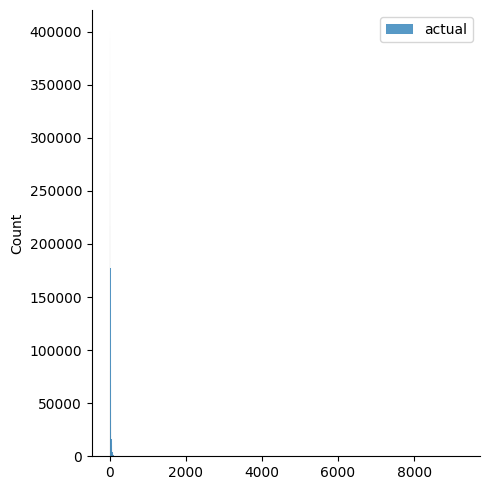

In [11]:
sns.displot(y_pred,label='Prediction')
sns.displot(y_train,label='actual')
plt.legend()

In [12]:
def read_dataframe(file_name):
    if file_name.endswith('.parquet'):
        df = pd.read_parquet(file_name)
    elif file_name.endswith('.csv'):
        # FIXED: Added 'pd.' before read_csv
        df = pd.read_csv(file_name) 
        
    df['duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
    # FIXED: Convert the duration to minutes
    df['duration'] = df['duration'].apply(lambda td: td.total_seconds() / 60)
    
    # FIXED: Filter out the outliers (typically trips between 1 and 60 minutes)
    df = df[(df.duration >= 1) & (df.duration <= 60)]
    
    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)

    return df


In [13]:
df_train = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-02.parquet')
df_val = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-01.parquet')

In [14]:
len(df_train) , len(df_val)

(3258717, 3571924)

In [15]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [16]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [17]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [18]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

6.439287708808353

In [19]:
import os

os.makedirs('models', exist_ok=True)
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [20]:
lr = Lasso(0.01)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

10.324181689096193